In [5]:
!pip install requests pandas

In [18]:
import random
import pandas as pd
def generate_customer():

    return {
        "Gender": random.choice(["Male","Female"]),
        "SeniorCitizen": random.randint(0,1),
        "Partner": random.choice(["Yes","No"]),
        "Dependents": random.choice(["Yes","No"]),
        "tenure": random.randint(0,72),

        "PhoneService": random.choice(["Yes","No"]),
        "MultipleLines": random.choice(["Yes","No","No phone service"]),

        "InternetService": random.choice(["DSL","Fiber optic","No"]),

        "OnlineSecurity": random.choice(["Yes","No","No internet service"]),
        "OnlineBackup": random.choice(["Yes","No","No internet service"]),
        "DeviceProtection": random.choice(["Yes","No","No internet service"]),
        "TechSupport": random.choice(["Yes","No","No internet service"]),
        "StreamingTV": random.choice(["Yes","No","No internet service"]),
        "StreamingMovies": random.choice(["Yes","No","No internet service"]),

        "Contract": random.choice(["Month-to-month","One year","Two year"]),

        "PaperlessBilling": random.choice(["Yes","No"]),

        "PaymentMethod": random.choice([
            "Electronic check",
            "Mailed check",
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]),

        "MonthlyCharges": round(random.uniform(20,120),2)
    }

customers = [generate_customer() for _ in range(1000)]
df = pd.DataFrame(customers)

In [24]:
import requests
import time
url = "https://customer-churn-prediction-suvb.onrender.com"
logs = []

for i in range(1000):

    payload = generate_customer()

    start = time.time()

    r = requests.post(url, json=payload)

    latency = time.time() - start

    logs.append({
        "request": i,
        "status": r.status_code,
        "latency": latency
    })

In [27]:
import pandas as pd

log_df = pd.DataFrame(logs)
log_df


,request,status,latency
0,0,405,0.103016
1,1,405,0.083931
2,2,405,0.057932
3,3,405,0.101881
4,4,405,0.087289
...,...,...,...
995,995,405,0.079111
996,996,405,0.090908
997,997,405,0.107324
998,998,405,0.111223


np.float64(0.0)

In [29]:
log_df["status"].value_counts()

,count
status,
405,1000


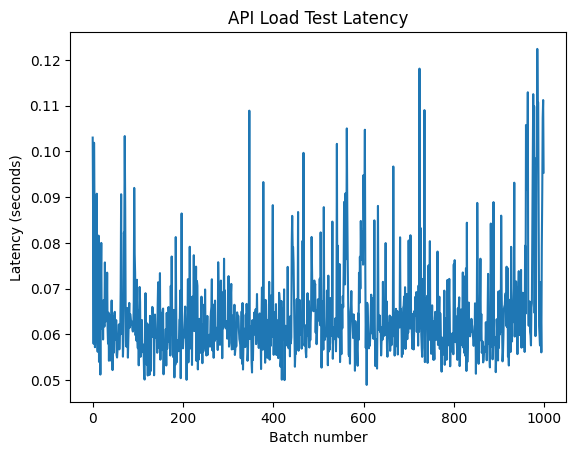

In [34]:
import matplotlib.pyplot as plt

plt.plot(log_df["latency"])
plt.xlabel("Batch number")
plt.ylabel("Latency (seconds)")
plt.title("API Load Test Latency")

plt.savefig("latency_plot.png", dpi=300)
plt.show()

<Axes: >

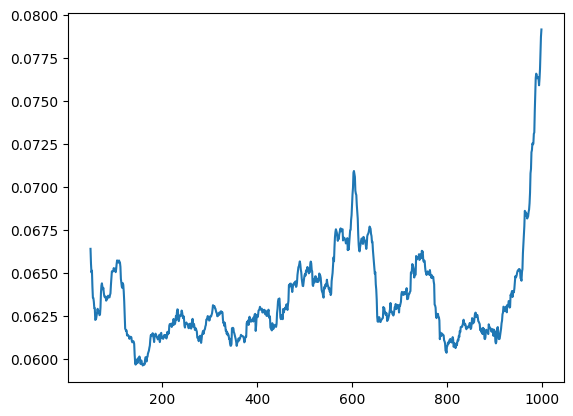

In [33]:
log_df["latency"].rolling(50).mean().plot()